Logistic Regression

1. Introduction to Logistic Regression
2. Why Logistic Regression Is Used for Classification
3. Generating a Simple Synthetic Dataset
4. Visualizing the Data
5. Training Logistic Regression
6. Understanding the Predictions
7. Evaluating the Model
8. What Happens When There Is No Useful Relationship in the Data?
9. Applying Logistic Regression to the Iris Dataset
10. Exploring the Effect of Different Features
11. Results and Observations

## 0. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

%matplotlib inline

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')

## 1. Introduction to Logistic Regression

Logistic regression predicts the **probability** of a categorical outcome (0 or 1)
by passing a linear score through the **sigmoid function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The sigmoid squashes any real number into the range (0, 1).

## 2. Why Logistic Regression Is Used for Classification

Its output is always between 0 and 1, so it can be read as a probability.
Applying a threshold (usually 0.5) turns that probability into a class label.

## 3. Generating a Simple Synthetic Dataset

500 samples of a single feature `x`, labeled by its sign: `y = 1` if `x > 0`, else `y = 0`.

In [2]:
n_samples = 500
np.random.seed(0)

X_syn = np.random.normal(size=n_samples)
y_syn = (X_syn > 0).astype(float)

print("First 5 features:", X_syn[:5])
print("First 5 labels  :", y_syn[:5])

First 5 features: [1.76405235 0.40015721 0.97873798 2.2408932  1.86755799]
First 5 labels  : [1. 1. 1. 1. 1.]


In [3]:
print("Min {:.4f}, Max {:.4f}".format(X_syn.min(), X_syn.max()))

Min -2.7726, Max 2.6962


## 4. Visualizing the Data

Plot each sample: feature on the x-axis, label on the y-axis.

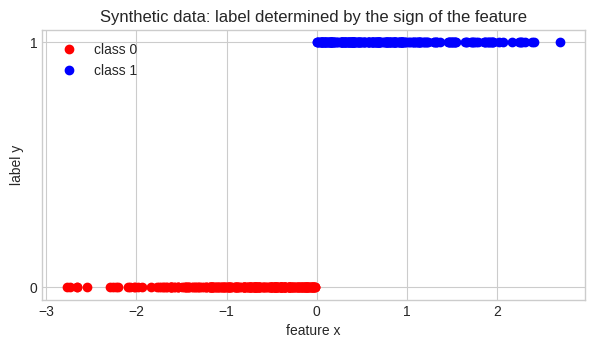

In [4]:
class0_x = X_syn[y_syn == 0]
class1_x = X_syn[y_syn == 1]

plt.figure(figsize=(7, 3.5))
plt.plot(class0_x, np.zeros_like(class0_x), 'o', color='red',  label='class 0')
plt.plot(class1_x, np.ones_like(class1_x),  'o', color='blue', label='class 1')
plt.title('Synthetic data: label determined by the sign of the feature')
plt.xlabel('feature x')
plt.ylabel('label y')
plt.yticks([0, 1])
plt.legend()
plt.show()

## 5. Training Logistic Regression

80/20 train-test split, then fit `LogisticRegression`. `reshape(-1, 1)` gives the
2-D shape scikit-learn expects.

In [5]:
X_syn_2d = X_syn.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_syn_2d, y_syn, test_size=0.2, random_state=0)

logreg_syn = LogisticRegression()
logreg_syn.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 6. Understanding the Predictions

Compare predicted labels against true labels for a few test samples.

In [6]:
y_pred_syn = logreg_syn.predict(X_test)

print("Feature values  :", np.round(X_test[:10].ravel(), 2))
print("True labels     :", y_test[:10].astype(int))
print("Predicted labels:", y_pred_syn[:10])

Feature values  : [-0.4   0.69  1.54 -0.12 -0.98  0.33 -0.04  0.22 -0.44 -0.83]
True labels     : [0 1 1 0 0 1 0 1 0 0]
Predicted labels: [0. 1. 1. 0. 0. 1. 0. 1. 0. 0.]


Plot the decision boundary: the sigmoid probability curve learned by the model, and the point where it crosses 0.5.

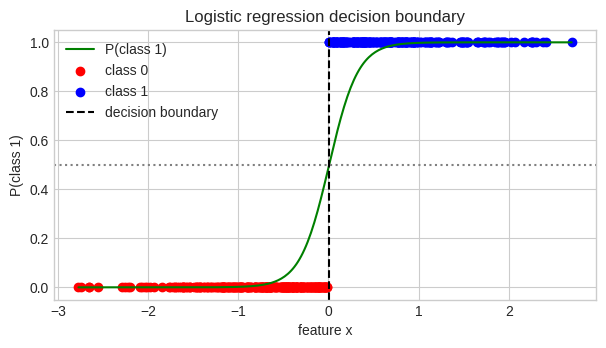

Decision boundary at x = 0.0071


In [7]:
x_range = np.linspace(X_syn.min(), X_syn.max(), 300).reshape(-1, 1)
probs = logreg_syn.predict_proba(x_range)[:, 1]

# decision boundary: where predicted probability = 0.5
boundary = -logreg_syn.intercept_[0] / logreg_syn.coef_[0][0]

plt.figure(figsize=(7, 3.5))
plt.plot(x_range, probs, color='green', label='P(class 1)')
plt.scatter(class0_x, np.zeros_like(class0_x), color='red', label='class 0')
plt.scatter(class1_x, np.ones_like(class1_x), color='blue', label='class 1')
plt.axvline(boundary, color='black', linestyle='--', label='decision boundary')
plt.axhline(0.5, color='gray', linestyle=':')
plt.title('Logistic regression decision boundary')
plt.xlabel('feature x')
plt.ylabel('P(class 1)')
plt.legend()
plt.show()

print('Decision boundary at x = {:.4f}'.format(boundary))

## 7. Evaluating the Model

Accuracy on the test set.

In [8]:
acc_separable = logreg_syn.score(X_test, y_test)
print('Accuracy {:.2f}'.format(acc_separable))

Accuracy 1.00


## 8. What Happens When There Is No Useful Relationship in the Data?

Same feature generation, but labels are assigned by position (first half = 0,
second half = 1) — unrelated to the feature value.

In [9]:
n_samples = 500
half = n_samples // 2

np.random.seed(4)
X_rand = np.random.normal(size=n_samples)
y_rand = np.array([0] * half + [1] * half)

print("Min {:.4f}, Max {:.4f}".format(X_rand.min(), X_rand.max()))

Min -2.4367, Max 2.7868


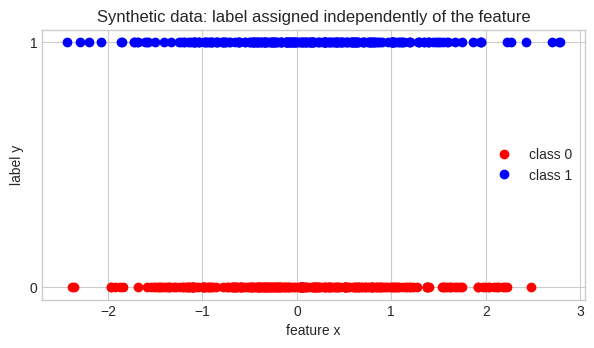

In [10]:
plt.figure(figsize=(7, 3.5))
plt.plot(X_rand[:half], y_rand[:half], 'o', color='red',  label='class 0')
plt.plot(X_rand[half:], y_rand[half:], 'o', color='blue', label='class 1')
plt.title('Synthetic data: label assigned independently of the feature')
plt.xlabel('feature x')
plt.ylabel('label y')
plt.yticks([0, 1])
plt.legend()
plt.show()

Train the same model on this dataset with the same split.

In [11]:
X_rand_2d = X_rand.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_rand_2d, y_rand, test_size=0.2, random_state=0)

logreg_rand = LogisticRegression()
logreg_rand.fit(X_train, y_train)

y_pred_rand = logreg_rand.predict(X_test)
acc_random = logreg_rand.score(X_test, y_test)
print('Accuracy {:.2f}'.format(acc_random))

Accuracy 0.50


Accuracy drops to ~0.50 — chance level, since the feature carries no information
about the label.

## 9. Applying Logistic Regression to the Iris Dataset

150 flowers, 4 measurements each, 3 species.

In [12]:
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
feature_names = iris_df.columns.values

print("Number of samples:", len(X_iris))
print(iris_df.head())

Number of samples: 150
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


Split 80/20 and fit logistic regression using all four features.
`solver='lbfgs', max_iter=125` ensures convergence.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=1)

logreg_iris = LogisticRegression(solver='lbfgs', max_iter=125)
logreg_iris.fit(X_train, y_train)

y_pred_iris = logreg_iris.predict(X_test)
acc_iris_all = logreg_iris.score(X_test, y_test)
print('Accuracy {:.2f}'.format(acc_iris_all))

Accuracy 0.97


## 10. Exploring the Effect of Different Features

Same model, but using only two features at a time (test size 0.4).

### 10.1 Sepal length and sepal width

In [14]:
print(feature_names[0] + " and " + feature_names[1])

X_train, X_test, y_train, y_test = train_test_split(
    X_iris[:, :2], y_iris, test_size=0.4, random_state=1)

logreg_sepal = LogisticRegression(solver='lbfgs', max_iter=125)
logreg_sepal.fit(X_train, y_train)

y_pred_sepal = logreg_sepal.predict(X_test)
acc_sepal = logreg_sepal.score(X_test, y_test)
print('Accuracy {:.2f}'.format(acc_sepal))

sepal length (cm) and sepal width (cm)
Accuracy 0.77


### 10.2 Petal length and petal width

In [15]:
print(feature_names[2] + " and " + feature_names[3])

X_train, X_test, y_train, y_test = train_test_split(
    X_iris[:, 2:], y_iris, test_size=0.4, random_state=1)

logreg_petal = LogisticRegression(solver='lbfgs', max_iter=125)
logreg_petal.fit(X_train, y_train)

y_pred_petal = logreg_petal.predict(X_test)
acc_petal = logreg_petal.score(X_test, y_test)
print('Accuracy {:.2f}'.format(acc_petal))

petal length (cm) and petal width (cm)
Accuracy 0.97


## 11. Results and Observations

In [16]:
results = pd.DataFrame({
    'Experiment': [
        'Synthetic — label depends on feature',
        'Synthetic — label independent of feature',
        'Iris — all 4 features',
        'Iris — sepal length + sepal width',
        'Iris — petal length + petal width',
    ],
    'Accuracy': [
        acc_separable,
        acc_random,
        acc_iris_all,
        acc_sepal,
        acc_petal,
    ],
})
results['Accuracy'] = results['Accuracy'].round(2)
print(results.to_string(index=False))

                              Experiment  Accuracy
    Synthetic — label depends on feature      1.00
Synthetic — label independent of feature      0.50
                   Iris — all 4 features      0.97
       Iris — sepal length + sepal width      0.77
       Iris — petal length + petal width      0.97


## 12. Key Takeaways

* Logistic regression maps a linear score to a probability via the sigmoid function,
  then thresholds it to predict a class.
* Works on linearly separable data and extends to more than two classes (Iris).
* Accuracy is bounded by the data — same algorithm, but 1.00 vs ~0.50 depending on
  whether a real relationship exists.
* Feature choice matters: petal measurements alone match the full-feature accuracy;
  sepal measurements alone do not.